# 01 — Tratamento e preparação dos dados

## Projeto: análise e previsão do NPS

**Responsável técnico:** Gabriel  
**Etapas do CRISP-DM:** compreensão e preparação dos dados  
**Arquivo de entrada:** `data/desafio_nps_fase_1.csv`  
**Arquivo de saída:** `data/processed/nps_tratado.csv`

---

## Contexto

A empresa possui informações sobre clientes, pedidos, entregas, atendimento e
satisfação. Antes da análise exploratória e da modelagem, precisamos verificar se
os dados estão completos, consistentes e adequados ao objetivo do projeto.

Este notebook foi organizado para que outras pessoas consigam acompanhar o
processo, entender as decisões tomadas e reproduzir os resultados.

## Objetivos

- Compreender a estrutura e a unidade de análise da base;
- Verificar valores ausentes, duplicidades e tipos de dados;
- Avaliar a coerência dos valores;
- Investigar possíveis outliers;
- Padronizar nomes e categorias;
- Criar variáveis derivadas úteis para a EDA e o modelo;
- Classificar o NPS em Detrator, Neutro e Promotor;
- Salvar a base tratada em `data/processed/nps_tratado.csv`.

## 1. Preparação do ambiente

Importamos apenas as bibliotecas necessárias para leitura, tratamento,
visualização e exportação dos dados.

In [54]:
# Manipulação e análise de dados
import pandas as pd

# Operações numéricas e criação de condições
import numpy as np

# Criação de gráficos
import matplotlib.pyplot as plt

# Criação da pasta de saída
import os

## 2. Carregamento da base

A base original será carregada da pasta `data`.

O tratamento será realizado em uma cópia chamada `df`. Assim, o DataFrame
`df_original` permanece disponível para comparação ao final do processo.

In [55]:
# Caminho do arquivo de entrada, considerando o notebook dentro de notebooks/
caminho_entrada = "../data/desafio_nps_fase_1.csv"

# Leitura da base original
df_original = pd.read_csv(caminho_entrada)

# Cópia utilizada durante o tratamento
df = df_original.copy()

# Dimensão inicial da base
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 2500
Quantidade de colunas: 19


### Resultado observado

A base foi carregada com **2.500 registros e 19 colunas**.

Cada linha reúne dados de um cliente e de um pedido. Como `order_id` identifica
a transação registrada, a unidade de análise adotada neste projeto é o **pedido**.

## 3. Reconhecimento da estrutura dos dados

Antes de alterar a base, observamos:

- As primeiras linhas;
- Os nomes das colunas;
- Os tipos armazenados;
- A quantidade de valores preenchidos;
- As estatísticas descritivas das variáveis numéricas.

In [56]:
# Visualização das primeiras linhas
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [57]:
# Lista de colunas disponíveis
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

In [58]:
# Tipos das colunas e quantidade de valores não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [59]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.50,721.83,1.00,625.75,1250.50,1875.25,2500.00
customer_age,2500.0,43.40,14.89,18.00,31.00,43.00,56.00,69.00
customer_tenure_months,2500.0,61.32,34.48,1.00,31.00,62.00,91.00,119.00
order_id,2500.0,51250.50,721.83,50001.00,50625.75,51250.50,51875.25,52500.00
order_value,2500.0,434.26,289.77,7.76,220.24,375.52,577.29,1983.81
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.00,5.00,6.00
discount_value,2500.0,29.75,29.23,0.02,8.88,20.94,40.83,230.33
payment_installments,2500.0,6.00,3.16,1.00,3.00,6.00,9.00,11.00
delivery_time_days,2500.0,8.02,3.77,2.00,5.00,8.00,11.00,14.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.00,3.00,8.00


### Resultado observado

A base contém:

- 13 colunas do tipo inteiro;
- 5 colunas do tipo decimal;
- 1 coluna categórica, `customer_region`.

Os valores de `customer_age` variam de **18 a 69 anos**, `nps_score` varia de
**0 a 10** e as variáveis financeiras estão armazenadas como números decimais.

Nesta versão da base, os tipos carregados são coerentes com o significado das
variáveis. Por isso, não será feita conversão automática de tipos.

## 4. Padronização dos nomes das colunas

Os nomes já estavam próximos de um padrão consistente. Mesmo assim, aplicamos
uma padronização simples para evitar espaços ou diferenças entre letras maiúsculas
e minúsculas.

O padrão adotado utiliza:

- Letras minúsculas;
- Remoção de espaços no início e no final;
- Sublinhado no lugar de espaços internos.

In [60]:
# Padronização dos nomes das colunas
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Conferência após a padronização
df.columns.tolist()

['customer_id',
 'customer_age',
 'customer_region',
 'customer_tenure_months',
 'order_id',
 'order_value',
 'items_quantity',
 'discount_value',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'freight_value',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'repeat_purchase_30d',
 'complaints_count',
 'csat_internal_score']

### Resultado observado

Os 19 nomes já estavam em letras minúsculas e separados por sublinhado. Portanto,
a padronização não alterou o significado nem a quantidade de colunas; ela apenas
garante consistência caso o processo seja executado novamente com outra versão da
base.

## 5. Diagnóstico inicial de qualidade

O diagnóstico reúne três informações por coluna:

- Tipo de dado;
- Quantidade de valores ausentes;
- Quantidade de valores únicos.

Essa visão permite identificar rapidamente colunas que exigem investigação.

In [61]:
# Diagnóstico simples por coluna
diagnostico = pd.DataFrame({
    "tipo_dado": df.dtypes.astype(str),
    "quantidade_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique(dropna=False)
})

diagnostico

,tipo_dado,quantidade_nulos,valores_unicos
customer_id,int64,0,2500
customer_age,int64,0,52
customer_region,object,0,5
customer_tenure_months,int64,0,119
order_id,int64,0,2500
order_value,float64,0,2457
items_quantity,int64,0,6
discount_value,float64,0,2050
payment_installments,int64,0,11
delivery_time_days,int64,0,13


### Resultado observado

O diagnóstico confirma que:

- Nenhuma coluna possui valores ausentes;
- `customer_id` e `order_id` possuem 2.500 valores únicos;
- `customer_region` possui 5 categorias;
- `repeat_purchase_30d` possui 2 valores possíveis;
- `nps_score` possui 101 valores diferentes, pois a base contém notas decimais.

Esses resultados serão detalhados nas próximas etapas.

## 6. Verificação de valores ausentes

Valores ausentes podem alterar contagens, médias e comparações. Primeiro
identificamos o problema; somente depois seria definida uma forma de tratamento.

In [62]:
# Quantidade de valores ausentes por coluna
valores_ausentes = df.isnull().sum()

# Exibe apenas colunas com pelo menos um valor ausente
valores_ausentes[valores_ausentes > 0]

Series([], dtype: int64)

In [63]:
# Quantidade total de valores ausentes
total_ausentes = df.isnull().sum().sum()

print(f"Total de valores ausentes: {total_ausentes}")

Total de valores ausentes: 0


### Resultado e decisão

A base possui **0 valores ausentes**.

Portanto:

- Nenhuma linha foi removida por ausência de dados;
- Nenhum valor foi preenchido por média, mediana ou outra regra;
- A base foi mantida sem alterações nesta etapa.

Essa decisão evita tratamentos desnecessários em dados que já estão completos.

## 7. Verificação de registros duplicados

São verificadas três situações:

1. Linhas completamente iguais;
2. `order_id` repetido;
3. `customer_id` repetido.

A verificação separada é importante porque identificadores diferentes representam
conceitos diferentes.

In [64]:
# Linhas completamente iguais
linhas_duplicadas = df.duplicated().sum()

# Identificadores de pedido repetidos
pedidos_duplicados = df["order_id"].duplicated().sum()

# Identificadores de cliente repetidos
clientes_duplicados = df["customer_id"].duplicated().sum()

print(f"Linhas completamente duplicadas: {linhas_duplicadas}")
print(f"order_id duplicados: {pedidos_duplicados}")
print(f"customer_id duplicados: {clientes_duplicados}")

Linhas completamente duplicadas: 0
order_id duplicados: 0
customer_id duplicados: 0


In [65]:
# Exibe as linhas completamente duplicadas, caso existam
df[df.duplicated(keep=False)]

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score


### Resultado e decisão

Não foram encontrados:

- Registros completamente duplicados;
- Pedidos com `order_id` repetido;
- Clientes com `customer_id` repetido.

Assim, **nenhuma linha foi removida**.

Nesta versão da base, cada registro representa um pedido e um cliente diferente.
Em uma futura atualização, um cliente repetido não deverá ser excluído
automaticamente, pois ele poderá ter realizado pedidos distintos.

## 8. Verificação dos tipos de dados

O tipo da variável determina quais operações, estatísticas e gráficos podem ser
aplicados.

Nesta etapa, comparamos o tipo carregado pelo pandas com o significado da coluna.

In [66]:
# Tipos armazenados em cada coluna
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

### Resultado e decisão

Os tipos estão coerentes com a base:

- Identificadores e contagens estão como inteiros;
- Valores monetários e scores decimais estão como `float`;
- `customer_region` está como texto;
- `repeat_purchase_30d` está representada pelos números 0 e 1.

Como não foi encontrada incompatibilidade, nenhuma conversão de tipo foi aplicada.

## 9. Validação de regras básicas

Além do tipo técnico, avaliamos se os valores respeitam regras simples do contexto,
como ausência de valores negativos e NPS dentro da escala de 0 a 10.

Os limites desta etapa são critérios de coerência adotados para o projeto.

In [67]:
# Contagem de registros que não atendem às regras definidas
validacao_regras = pd.Series({
    "Idade menor que zero": (df["customer_age"] < 0).sum(),
    "Idade maior que 120": (df["customer_age"] > 120).sum(),
    "Tempo de relacionamento negativo": (df["customer_tenure_months"] < 0).sum(),
    "Valor do pedido negativo": (df["order_value"] < 0).sum(),
    "Quantidade de itens menor ou igual a zero": (df["items_quantity"] <= 0).sum(),
    "Desconto negativo": (df["discount_value"] < 0).sum(),
    "Tempo de entrega menor ou igual a zero": (df["delivery_time_days"] <= 0).sum(),
    "Dias de atraso negativos": (df["delivery_delay_days"] < 0).sum(),
    "Frete negativo": (df["freight_value"] < 0).sum(),
    "Contatos com atendimento negativos": (
        df["customer_service_contacts"] < 0
    ).sum(),
    "Tempo de resolução negativo": (df["resolution_time_days"] < 0).sum(),
    "NPS fora da escala de 0 a 10": (
        ~df["nps_score"].between(0, 10)
    ).sum(),
    "Recompra fora das categorias 0 e 1": (
        ~df["repeat_purchase_30d"].isin([0, 1])
    ).sum(),
    "Quantidade de reclamações negativa": (
        df["complaints_count"] < 0
    ).sum()
})

validacao_regras.to_frame(name="quantidade_registros_invalidos")

,quantidade_registros_invalidos
Idade menor que zero,0
Idade maior que 120,0
Tempo de relacionamento negativo,0
Valor do pedido negativo,0
Quantidade de itens menor ou igual a zero,0
Desconto negativo,0
Tempo de entrega menor ou igual a zero,0
Dias de atraso negativos,0
Frete negativo,0
Contatos com atendimento negativos,0


### Resultado e decisão

Todas as regras retornaram **0 registros inválidos**.

Isso indica que, nesta versão da base:

- Não há idades fora do intervalo verificado;
- Não há valores financeiros negativos;
- Não há tempos ou quantidades negativas;
- Todas as notas de NPS estão entre 0 e 10;
- `repeat_purchase_30d` contém somente 0 e 1.

Nenhuma correção foi necessária.

## 10. Padronização de `customer_region`

Categorias com diferenças de espaços ou grafia podem ser interpretadas como
categorias distintas.

Primeiro observamos os valores existentes. Depois aplicamos uma padronização
simples e comparamos o resultado.

In [68]:
# Remove espaços, converte temporariamente para letras minúsculas
# e substitui pelas grafias definidas para o projeto.
df["customer_region"] = (
    df["customer_region"]
    .str.strip()
    .str.lower()
    .replace({
        "norte": "Norte",
        "nordeste": "Nordeste",
        "centro-oeste": "Centro-Oeste",
        "centro oeste": "Centro-Oeste",
        "sudeste": "Sudeste",
        "sul": "Sul"
    })
)

# Distribuição após a padronização
regioes_depois = df["customer_region"].value_counts(dropna=False)

regioes_depois

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

### Resultado e decisão

A base já possuía cinco categorias corretamente escritas:

- Sul: 521 registros;
- Sudeste: 520;
- Norte: 506;
- Nordeste: 485;
- Centro-Oeste: 468.

As contagens antes e depois permaneceram iguais. Portanto, não havia categorias
duplicadas por diferenças de grafia, mas a etapa foi mantida para garantir
consistência em futuras execuções.

## 11. Investigação de possíveis outliers

Valores extremos podem representar erros, mas também podem registrar situações
reais e importantes.

A investigação utiliza apenas:

- Estatísticas descritivas;
- Histogramas;
- Boxplots.

Nenhum registro será removido automaticamente.

In [69]:
# Variáveis previstas no escopo para investigação
colunas_outliers = [
    "customer_age",
    "items_quantity",
    "delivery_delay_days",
    "freight_value",
    "delivery_attempts",
    "customer_service_contacts",
    "resolution_time_days",
]

# Estatísticas das variáveis selecionadas
df[colunas_outliers].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,43.40,14.89,18.00,31.00,43.0,56.00,69.00
items_quantity,2500.0,3.47,1.69,1.00,2.00,3.0,5.00,6.00
delivery_delay_days,2500.0,2.19,1.45,0.00,1.00,2.0,3.00,8.00
freight_value,2500.0,38.22,12.08,2.62,29.93,38.5,46.27,76.13
delivery_attempts,2500.0,2.01,0.82,1.00,1.00,2.0,3.00,3.00
customer_service_contacts,2500.0,1.52,1.23,0.00,1.00,1.0,2.00,7.00
resolution_time_days,2500.0,5.49,3.46,0.00,2.00,6.0,8.00,11.00


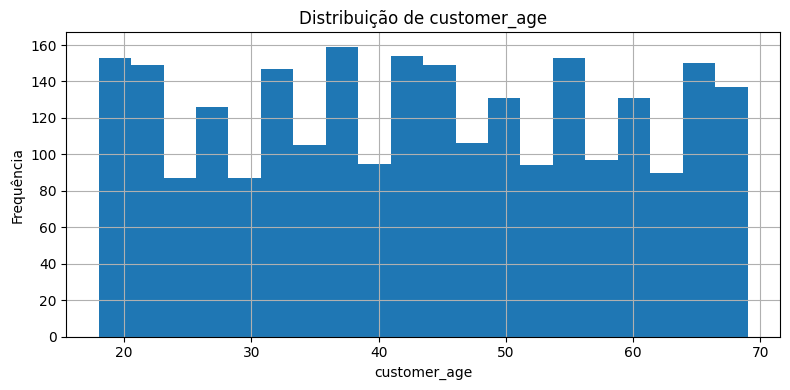

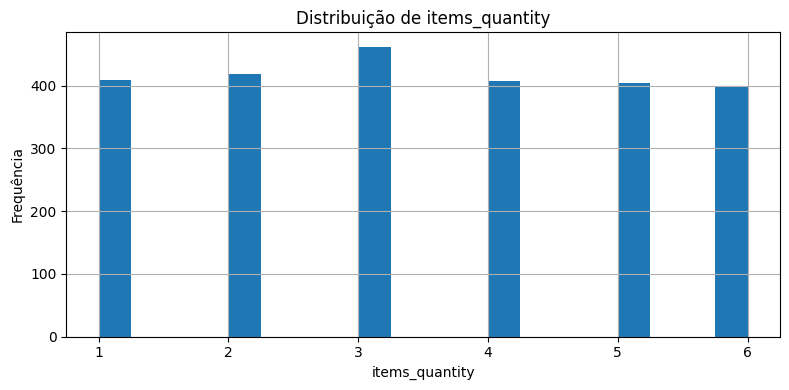

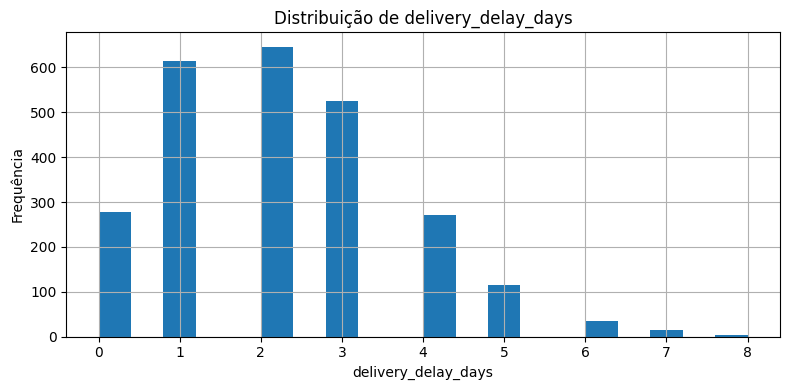

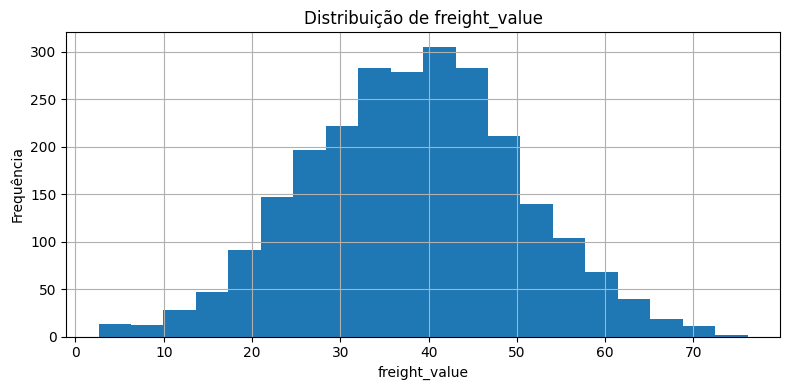

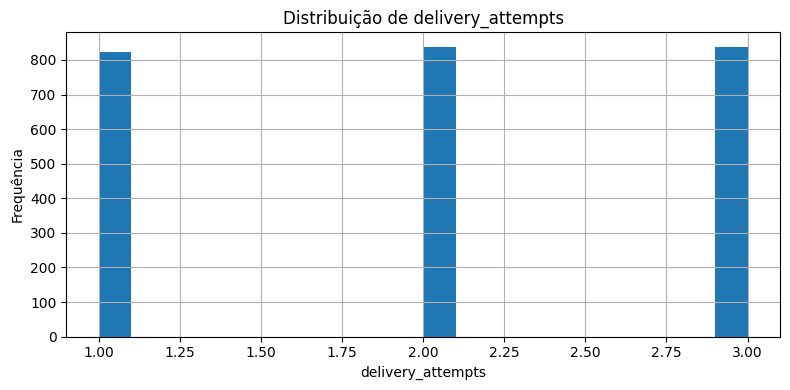

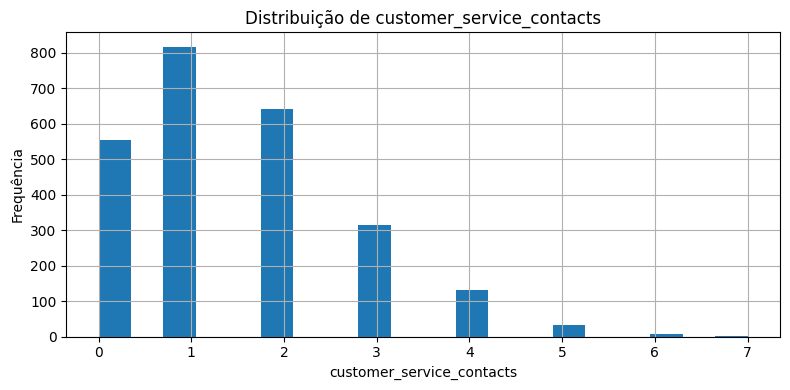

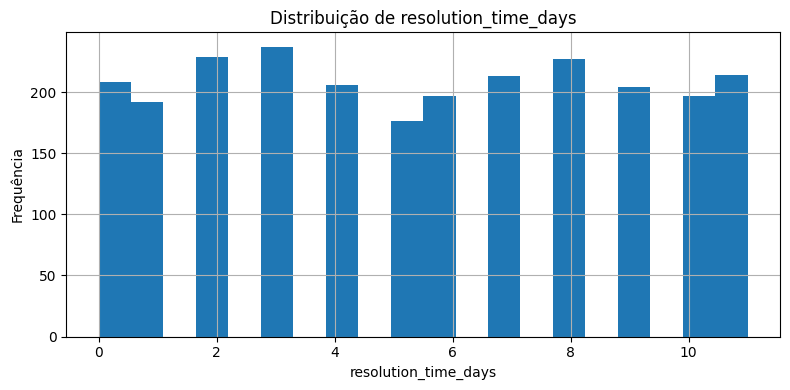

In [70]:
# Histogramas para observar a distribuição
for coluna in colunas_outliers:
    plt.figure(figsize=(8, 4))
    df[coluna].hist(bins=20)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

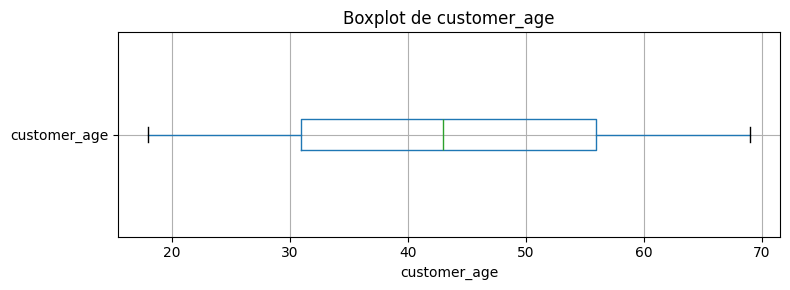

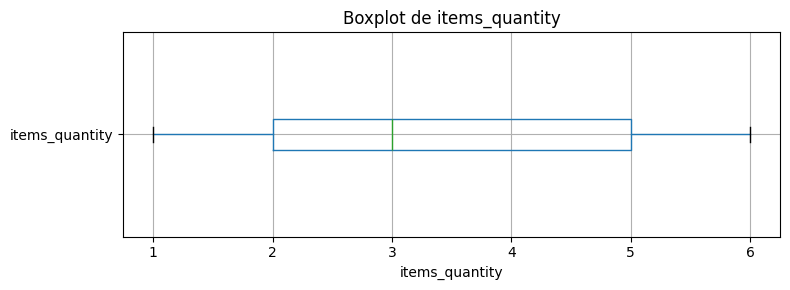

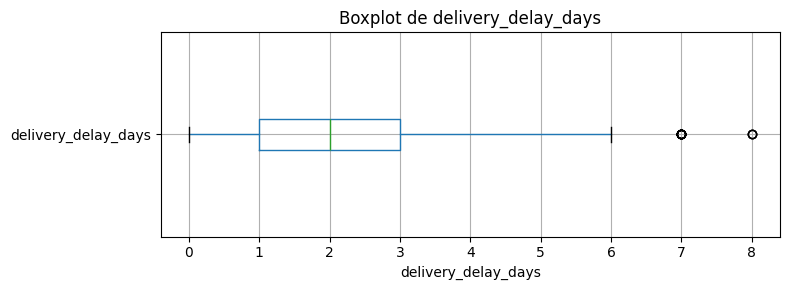

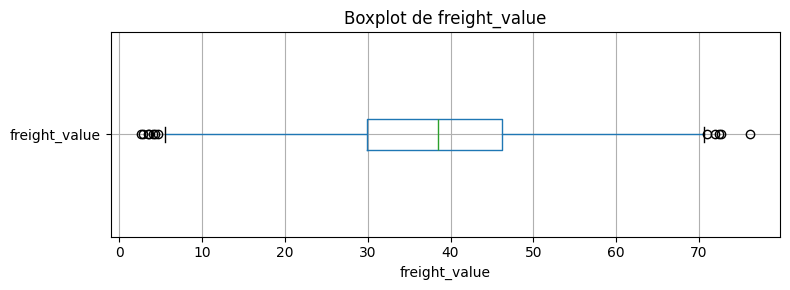

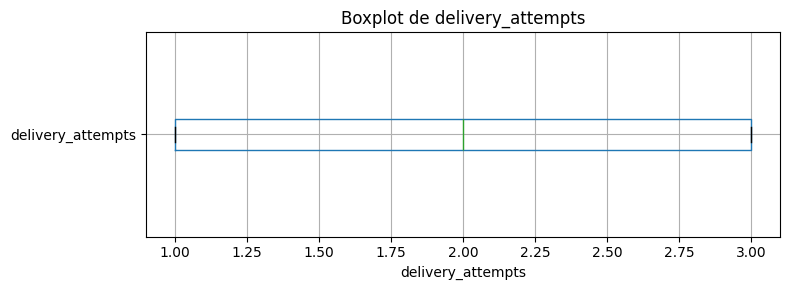

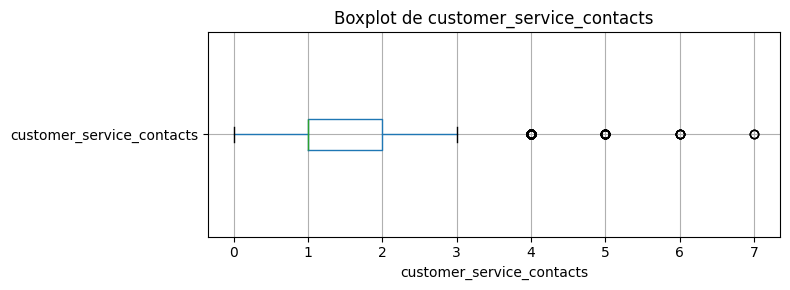

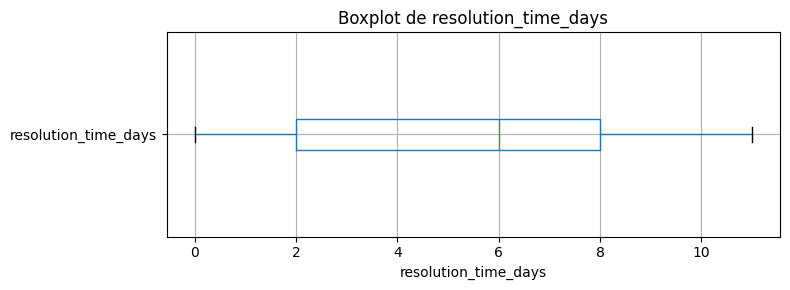

In [71]:
# Boxplots para observar possíveis valores extremos
for coluna in colunas_outliers:
    plt.figure(figsize=(8, 3))
    df.boxplot(column=coluna, vert=False)
    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)
    plt.tight_layout()
    plt.show()

### Resultado e decisão

Os boxplots indicam possíveis valores extremos em atraso e frete. Entretanto,
esses valores continuam dentro dos limites registrados pela base e podem representar
experiências reais.

Por isso, **nenhum outlier foi removido**. A decisão evita eliminar justamente os
casos que podem ajudar a explicar uma experiência negativa.

## 12. Criação de variáveis derivadas

Serão criadas apenas variáveis diretamente relacionadas ao escopo:

- `teve_atraso`;
- `atraso_percentual`;
- `contato_com_atendimento`;
- `teve_reclamacao`;
- `faixa_etaria`;
- `faixa_tenure`;
- `classe_nps`.

As colunas originais serão preservadas.

### 12.1 Indicador de atraso

A variável `teve_atraso` foi criada para identificar se o pedido apresentou pelo
menos um dia de atraso na entrega.

A classificação utilizada foi:

- `0`: pedido sem atraso;
- `1`: pedido com atraso.

In [72]:
# Cria o indicador binário de atraso
df["teve_atraso"] = np.where(
    df["delivery_delay_days"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atraso = pd.DataFrame({
    "quantidade": df["teve_atraso"].value_counts().sort_index(),
    "percentual": (
        df["teve_atraso"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atraso

,quantidade,percentual
teve_atraso,,
0,277,11.08
1,2223,88.92


### 12.2 Indicador de contato com o atendimento

A variável `contato_com_atendimento` foi criada para identificar se o cliente
precisou entrar em contato com a equipe de atendimento.

A classificação utilizada foi:

- `0`: nenhum contato registrado;
- `1`: pelo menos um contato registrado.

In [73]:
# Cria o indicador binário de atendimento
df["contato_com_atendimento"] = np.where(
    df["customer_service_contacts"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_atendimento = pd.DataFrame({
    "quantidade": df["contato_com_atendimento"].value_counts().sort_index(),
    "percentual": (
        df["contato_com_atendimento"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_atendimento

,quantidade,percentual
contato_com_atendimento,,
0,554,22.16
1,1946,77.84


### 12.3 Indicador de reclamação

A variável `teve_reclamacao` foi criada para identificar se existe pelo menos uma
reclamação registrada para o pedido.

A classificação utilizada foi:

- `0`: nenhuma reclamação registrada;
- `1`: uma ou mais reclamações registradas.

In [74]:
# Cria o indicador binário de reclamação
df["teve_reclamacao"] = np.where(
    df["complaints_count"] > 0,
    1,
    0
)

# Quantidade e percentual de pedidos em cada situação
resumo_reclamacao = pd.DataFrame({
    "quantidade": df["teve_reclamacao"].value_counts().sort_index(),
    "percentual": (
        df["teve_reclamacao"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

resumo_reclamacao

,quantidade,percentual
teve_reclamacao,,
0,23,0.92
1,2477,99.08


### Síntese dos indicadores operacionais

Os três indicadores criados apresentam alta concentração na categoria `1`:

| Indicador | Quantidade com ocorrência | Percentual |
|---|---:|---:|
| Pedido com atraso | 2.223 | 88,92% |
| Contato com atendimento | 1.946 | 77,84% |
| Pedido com reclamação | 2.477 | 99,08% |

Os resultados mostram que atraso, atendimento e reclamação são eventos frequentes
na base analisada.

Entretanto, as frequências não demonstram que esses fatores causam redução no
NPS. Elas apenas orientam as hipóteses que deverão ser investigadas na EDA.

Também será necessário considerar que os grupos são desbalanceados, principalmente
no indicador de reclamação. Por isso, as variáveis numéricas originais devem ser
preservadas:

- `delivery_delay_days`;
- `customer_service_contacts`;
- `complaints_count`.

Essas colunas permitem análises mais detalhadas do que os indicadores binários.

### 12.4 Atraso percentual

A variável compara os dias de atraso com o tempo de entrega:

`delivery_delay_days / delivery_time_days`

A condição verifica se `delivery_time_days` é maior que zero antes da divisão.

In [75]:
# Calcula o atraso proporcional ao tempo de entrega
df["atraso_percentual"] = np.where(
    df["delivery_time_days"] > 0,
    df["delivery_delay_days"] / df["delivery_time_days"],
    np.nan
)

# Estatísticas da nova variável
df["atraso_percentual"].describe().round(2)

count    2500.00
mean        0.38
std         0.41
min         0.00
25%         0.14
50%         0.25
75%         0.50
max         3.50
Name: atraso_percentual, dtype: float64

### Resultado observado e limitação

O atraso percentual apresenta:

- Média de **0,38**, equivalente a 38%;
- Mediana de **0,25**, equivalente a 25%;
- Máximo de **3,50**, equivalente a 350%.

Um valor acima de 100% ocorre quando os dias de atraso são maiores que o tempo
de entrega usado no denominador. O cálculo está matematicamente correto, mas sua
interpretação depende da definição exata de `delivery_time_days`.

Faremos a verificações das variáveis para identificar possíveis distorções.

In [76]:
# Identifica pedidos em que os dias de atraso são maiores
# que o tempo total de entrega.
inconsistencias_atraso = df[
    df["delivery_delay_days"] > df["delivery_time_days"]
]

print(
    "Quantidade de registros com atraso maior "
    f"que o tempo total: {len(inconsistencias_atraso)}"
)

inconsistencias_atraso[
    [
        "order_id",
        "delivery_time_days",
        "delivery_delay_days"
    ]
].head(10)

Quantidade de registros com atraso maior que o tempo total: 121


,order_id,delivery_time_days,delivery_delay_days
5,50006,4,5
18,50019,3,4
41,50042,2,3
46,50047,4,6
58,50059,2,3
61,50062,3,4
71,50072,2,6
113,50114,3,4
152,50153,2,3
184,50185,3,5


In [77]:
# Calcula o percentual dos registros divergentes
percentual_inconsistencias = (
    len(inconsistencias_atraso) / len(df) * 100
)

# Calcula a diferença dos registros totais pelos inconsistentes
percentual_restante = 100 - percentual_inconsistencias

print(
    f"Percentual de registros inconsistentes: "
    f"{percentual_inconsistencias:.2f}%"
)

print(
    f"Percentual de registros restantes: "
    f"{percentual_restante:.2f}%"
)

Percentual de registros inconsistentes: 4.84%
Percentual de registros restantes: 95.16%


In [78]:
# ## modificando a copia do DataFrame original
# df.drop(
#     df[
#         df["delivery_delay_days"] > df["delivery_time_days"]
#     ].index,
#     inplace=True
# )

## Validação entre tempo total de entrega e dias de atraso

De acordo com o dicionário de dados:

- `delivery_time_days` representa o **tempo total de entrega**;
- `delivery_delay_days` representa a **quantidade de dias de atraso**.

Com base nessas definições, espera-se que:

`delivery_delay_days <= delivery_time_days`

Isso ocorre porque os dias de atraso fazem parte do tempo total da entrega e,
portanto, não deveriam ser superiores a ele.

### Resultado da validação

Foram identificados:

- **121 registros inconsistentes**, equivalentes a **4,84% da base**;
- **2.379 registros dentro da regra esperada**, equivalentes a **95,16% da base**.

Nos registros inconsistentes, foi encontrada a seguinte condição:

`delivery_delay_days > delivery_time_days`

### Interpretação

Esse resultado indica uma possível divergência entre os valores registrados e a
definição apresentada no dicionário de dados.

Com as informações disponíveis, ainda não é possível determinar se:

1. os valores foram registrados incorretamente; ou
2. `delivery_time_days` possui um significado diferente do documentado, como prazo
   previsto em vez de tempo total realizado.

### Decisão adotada

Os registros serão preservados para não eliminar informações sem evidência
suficiente de erro.

Entretanto, a variável `atraso_percentual` não será utilizada em análises
conclusivas ou na modelagem até que o significado das colunas seja confirmado
com a fonte responsável pelos dados.

Enquanto essa validação não ocorrer, as análises poderão utilizar separadamente:

- `delivery_delay_days`;
- `delivery_time_days`;
- `teve_atraso`.

In [79]:
# Identifica pedidos sem atraso.
registros_sem_atraso = df[
    df["delivery_delay_days"] == 0
]

print(
     f"Quantidade de registros sem atraso: {len(registros_sem_atraso)}"
)

registros_sem_atraso[
    [
        "order_id",
        "delivery_time_days",
        "delivery_delay_days"
    ]
].head(10)

Quantidade de registros sem atraso: 277


,order_id,delivery_time_days,delivery_delay_days
22,50023,2,0
43,50044,4,0
78,50079,13,0
79,50080,10,0
81,50082,12,0
110,50111,7,0
115,50116,9,0
116,50117,9,0
117,50118,3,0
141,50142,9,0


In [80]:
# Calcula o percentual dos registros divergentes
percentual_sem_atraso = (
    len(registros_sem_atraso) / len(df) * 100
)

# Calcula a diferença dos registros totais pelos inconsistentes
percentual_restante = 100 - percentual_sem_atraso

print(
    f"Percentual de registros sem atraso: "
    f"{percentual_sem_atraso:.2f}%"
)

print(
    f"Percentual de registros restantes: "
    f"{percentual_restante:.2f}%"
)

Percentual de registros sem atraso: 11.08%
Percentual de registros restantes: 88.92%


## Distribuição dos pedidos por ocorrência de atraso

Para identificar a frequência de atrasos na base, os pedidos foram separados em
dois grupos:

- **Sem atraso:** `delivery_delay_days = 0`;
- **Com atraso:** `delivery_delay_days > 0`.

### Resultado observado

Dos **2.500 pedidos** analisados:

- **277 pedidos não apresentaram atraso**, correspondendo a **11,08% da base**;
- **2.223 pedidos apresentaram pelo menos um dia de atraso**, correspondendo a
  **88,92% da base**.

### Interpretação

A maior parte dos pedidos registrados na base apresenta algum nível de atraso.

Esse resultado indica que o atraso é um comportamento frequente no conjunto de
dados e merece atenção nas próximas etapas da análise exploratória.

Entretanto, essa frequência isoladamente não permite concluir que o atraso seja
a causa de notas mais baixas de NPS. Para avaliar essa possível relação, será
necessário comparar:

- A distribuição do `nps_score` entre pedidos com e sem atraso;
- A média e a mediana do NPS em cada grupo;
- A quantidade de Detratores, Neutros e Promotores em cada situação.

### Decisão analítica

Será criada a variável binária `teve_atraso` para facilitar as comparações:

- `0`: pedido sem atraso;
- `1`: pedido com atraso.

A variável original `delivery_delay_days` também será preservada, pois ela informa
a quantidade de dias de atraso e permite análises mais detalhadas.

### 12.5 Faixa etária

A idade original será mantida como número. A nova coluna será usada apenas para
facilitar segmentações e comparações na EDA.

Os intervalos são uma decisão analítica deste projeto.

In [81]:
# Limites e rótulos das faixas etárias
limites_idade = [0, 24, 34, 44, 54, 64, np.inf]

rotulos_idade = [
    "Até 24 anos",
    "25 a 34 anos",
    "35 a 44 anos",
    "45 a 54 anos",
    "55 a 64 anos",
    "65 anos ou mais"
]

# Criação da faixa etária
df["faixa_etaria"] = pd.cut(
    df["customer_age"],
    bins=limites_idade,
    labels=rotulos_idade,
    include_lowest=True
)

# Distribuição das faixas
df["faixa_etaria"].value_counts(sort=False, dropna=False)

faixa_etaria
Até 24 anos        344
25 a 34 anos       461
35 a 44 anos       509
45 a 54 anos       480
55 a 64 anos       468
65 anos ou mais    238
Name: count, dtype: int64

### Resultado observado

Todos os registros receberam uma faixa etária.

A maior faixa é **35 a 44 anos**, com 509 registros. A menor é **65 anos ou
mais**, com 238 registros. As demais faixas também possuem quantidade suficiente
para comparações exploratórias.

A coluna `customer_age` foi preservada para não perder a informação original.

### 12.6 Faixa de tempo de relacionamento

A variável `customer_tenure_months` será mantida. A nova coluna agrupa os clientes
por tempo de relacionamento para facilitar comparações na EDA.

Os intervalos também são uma decisão analítica deste projeto.

In [82]:
# Limites e rótulos das faixas de relacionamento
limites_tenure = [0, 12, 24, 48, 72, np.inf]

rotulos_tenure = [
    "Até 12 meses",
    "13 a 24 meses",
    "25 a 48 meses",
    "49 a 72 meses",
    "Mais de 72 meses"
]

# Criação da faixa de relacionamento
df["faixa_tenure"] = pd.cut(
    df["customer_tenure_months"],
    bins=limites_tenure,
    labels=rotulos_tenure,
    include_lowest=True
)

# Distribuição das faixas
df["faixa_tenure"].value_counts(sort=False, dropna=False)

faixa_tenure
Até 12 meses         242
13 a 24 meses        247
25 a 48 meses        473
49 a 72 meses        497
Mais de 72 meses    1041
Name: count, dtype: int64

### Resultado observado

Todos os registros receberam uma faixa de relacionamento.

O maior grupo é **Mais de 72 meses**, com 1.041 registros. Isso mostra que uma
parte relevante da base possui relacionamento mais longo com a empresa.

A coluna numérica original foi mantida para análises que precisem do número exato
de meses.

## 13. Classificação do NPS

A base possui notas decimais entre 0 e 10. Para que todos os valores recebam uma
classe, adotamos intervalos contínuos:

- **Detrator:** nota menor ou igual a 6;
- **Neutro:** nota maior que 6 e menor ou igual a 8;
- **Promotor:** nota maior que 8 e menor ou igual a 10.

Essa é uma adaptação operacional da regra proposta no escopo. A nota original será
preservada.

In [83]:
# Conferência dos limites da variável antes da classificação
print(f"Menor nota de NPS: {df['nps_score'].min()}")
print(f"Maior nota de NPS: {df['nps_score'].max()}")

# Registros fora da escala esperada
df[~df["nps_score"].between(0, 10)]

Menor nota de NPS: 0.0
Maior nota de NPS: 10.0


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,teve_atraso,contato_com_atendimento,teve_reclamacao,atraso_percentual,faixa_etaria,faixa_tenure


In [84]:
# Função de classificação do NPS
def classificar_nps(nota):
    # Mantém ausente caso a nota esteja ausente
    if pd.isna(nota):
        return np.nan

    # Notas até 6
    if nota <= 6:
        return "Detrator"

    # Notas acima de 6 até 8
    elif nota <= 8:
        return "Neutro"

    # Notas acima de 8 até 10
    else:
        return "Promotor"

# Criação da classe
df["classe_nps"] = df["nps_score"].apply(classificar_nps)

# Quantidade e percentual por classe
resumo_classes_nps = pd.DataFrame({
    "quantidade": df["classe_nps"].value_counts(),
    "percentual": (
        df["classe_nps"].value_counts(normalize=True) * 100
    ).round(2)
})

resumo_classes_nps

,quantidade,percentual
classe_nps,,
Detrator,1851,74.04
Neutro,448,17.92
Promotor,201,8.04


In [85]:
# Conferência entre as notas e as classes atribuídas
pd.crosstab(
    df["nps_score"],
    df["classe_nps"],
    margins=True
)

classe_nps,Detrator,Neutro,Promotor,All
nps_score,,,,
0.0,158,0,0,158
0.1,8,0,0,8
0.2,14,0,0,14
0.3,10,0,0,10
0.4,14,0,0,14
...,...,...,...,...
9.7,0,0,3,3
9.8,0,0,4,4
9.9,0,0,3,3


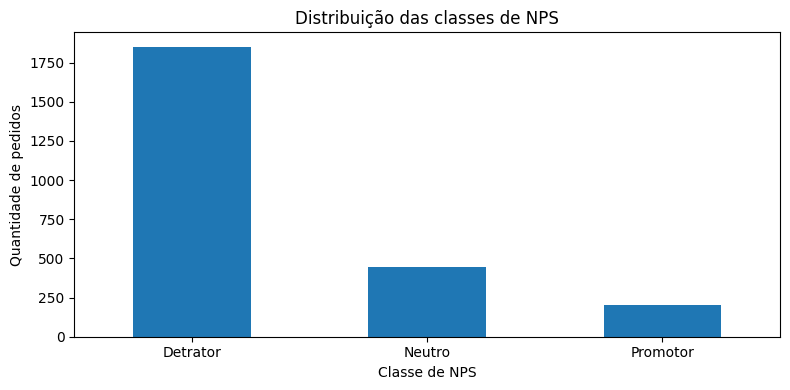

In [86]:
# Ordem das classes no gráfico
ordem_nps = ["Detrator", "Neutro", "Promotor"]

# Contagem organizada na ordem desejada
contagem_nps = (
    df["classe_nps"]
    .value_counts()
    .reindex(ordem_nps)
)

# Gráfico de barras
plt.figure(figsize=(8, 4))
contagem_nps.plot(kind="bar")
plt.title("Distribuição das classes de NPS")
plt.xlabel("Classe de NPS")
plt.ylabel("Quantidade de pedidos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Resultado observado

A classificação gerou:

- 1.851 Detratores (**74,04%**);
- 448 Neutros (**17,92%**);
- 201 Promotores (**8,04%**).

A base apresenta forte concentração na classe Detrator. Esse desbalanceamento
deverá ser considerado na etapa de modelagem, mas o tratamento específico pertence
ao notebook do item 4.

Para as próximas etapas:

- `nps_score` poderá ser utilizado como alvo de regressão;
- `classe_nps` poderá ser utilizada como alvo de classificação.

## 14. Cuidado com o momento de coleta das variáveis

O objetivo do desafio é antecipar o NPS antes da aplicação da pesquisa.

Por isso, antes da modelagem, será necessário verificar quando cada variável foi
registrada. Uma informação disponível somente depois do NPS não poderá ser usada
como entrada do modelo.

Neste notebook, nenhuma coluna original será excluída por essa razão. A decisão
será tomada no notebook de modelagem, após a validação da linha do tempo dos
dados.

## 15. Validação das variáveis criadas

Antes da exportação, verificamos:

- Valores ausentes nas novas colunas;
- Quantidade de linhas e colunas;
- Duplicidades após as transformações.

In [87]:
# Variáveis criadas neste notebook
colunas_derivadas = [
    "teve_atraso",
    "faixa_etaria",
    "faixa_tenure",
    "classe_nps"
]

# Valores ausentes nas variáveis derivadas
df[colunas_derivadas].isnull().sum()

teve_atraso     0
faixa_etaria    0
faixa_tenure    0
classe_nps      0
dtype: int64

In [88]:
# Comparação entre a base original e a base tratada
resumo_final = pd.DataFrame({
    "indicador": [
        "Quantidade de linhas",
        "Quantidade de colunas",
        "Total de valores ausentes",
        "Linhas duplicadas"
    ],
    "base_original": [
        df_original.shape[0],
        df_original.shape[1],
        df_original.isnull().sum().sum(),
        df_original.duplicated().sum()
    ],
    "base_tratada": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

resumo_final

,indicador,base_original,base_tratada
0,Quantidade de linhas,2500,2500
1,Quantidade de colunas,19,26
2,Total de valores ausentes,0,0
3,Linhas duplicadas,0,0


### Resultado da validação

A base tratada possui:

- 2.500 linhas, a mesma quantidade da base original;
- 24 colunas, sendo 19 originais e 5 derivadas;
- 0 valores ausentes;
- 0 linhas duplicadas.

As transformações não eliminaram registros e não criaram problemas de qualidade.

## 16. Organização das colunas

As colunas serão organizadas por assunto para facilitar a leitura do arquivo final:

1. Identificação;
2. Perfil do cliente;
3. Pedido;
4. Logística;
5. Atendimento;
6. Indicadores e satisfação.

Nenhuma coluna original será excluída.

In [89]:
# Ordem final das colunas
colunas_finais = [
    # Identificação
    "customer_id",
    "order_id",

    # Perfil do cliente
    "customer_age",
    "faixa_etaria",
    "customer_region",
    "customer_tenure_months",
    "faixa_tenure",

    # Pedido
    "order_value",
    "items_quantity",
    "discount_value",
    "payment_installments",

    # Logística
    "delivery_time_days",
    "delivery_delay_days",
    "teve_atraso",
    "freight_value",
    "delivery_attempts",

    # Atendimento
    "customer_service_contacts",
    "resolution_time_days",
    "complaints_count",

    # Indicadores e satisfação
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score",
    "classe_nps"
]

# Reorganização da base
df = df[colunas_finais].copy()

# Conferência da estrutura final
df.head()

,customer_id,order_id,customer_age,faixa_etaria,customer_region,customer_tenure_months,faixa_tenure,order_value,items_quantity,discount_value,...,teve_atraso,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,repeat_purchase_30d,csat_internal_score,nps_score,classe_nps
0,1,50001,63,55 a 64 anos,Nordeste,14,13 a 24 meses,139.73,4,39.35,...,1,55.53,3,0,4,3,0,6.5,6.9,Neutro
1,2,50002,20,Até 24 anos,Sul,1,Até 12 meses,458.95,2,9.51,...,1,28.23,3,0,10,3,0,0.0,2.4,Detrator
2,3,50003,46,45 a 54 anos,Nordeste,111,Mais de 72 meses,507.06,5,42.82,...,1,40.99,1,4,5,7,0,1.5,4.8,Detrator
3,4,50004,52,45 a 54 anos,Centro-Oeste,117,Mais de 72 meses,302.19,2,19.58,...,1,35.24,3,1,11,4,0,0.3,5.9,Detrator
4,5,50005,56,55 a 64 anos,Norte,50,49 a 72 meses,253.06,1,29.37,...,1,39.32,1,1,0,3,0,7.9,6.1,Neutro


## 17. Exportação da base tratada

A base será salva na pasta `data/processed`, mantendo o arquivo original separado.

O parâmetro `index=False` evita a criação de uma coluna adicional com o índice do
DataFrame.

In [90]:
# Pasta de saída
pasta_saida = "../data/processed"

# Cria a pasta se ela ainda não existir
os.makedirs(pasta_saida, exist_ok=True)

# Caminho completo do arquivo tratado
caminho_saida = "../data/processed/nps_tratado.csv"

# Exportação da base
df.to_csv(
    caminho_saida,
    index=False,
    encoding="utf-8"
)

print(f"Base tratada salva em: {caminho_saida}")
print(f"Dimensão final: {df.shape}")

Base tratada salva em: ../data/processed/nps_tratado.csv
Dimensão final: (2500, 23)


In [91]:
# Releitura do arquivo para confirmar a exportação
df_validacao = pd.read_csv("../data/processed/nps_tratado.csv")

print(f"Linhas do arquivo salvo: {df_validacao.shape[0]}")
print(f"Colunas do arquivo salvo: {df_validacao.shape[1]}")

df_validacao.head()

Linhas do arquivo salvo: 2500
Colunas do arquivo salvo: 23


,customer_id,order_id,customer_age,faixa_etaria,customer_region,customer_tenure_months,faixa_tenure,order_value,items_quantity,discount_value,...,teve_atraso,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,repeat_purchase_30d,csat_internal_score,nps_score,classe_nps
0,1,50001,63,55 a 64 anos,Nordeste,14,13 a 24 meses,139.73,4,39.35,...,1,55.53,3,0,4,3,0,6.5,6.9,Neutro
1,2,50002,20,Até 24 anos,Sul,1,Até 12 meses,458.95,2,9.51,...,1,28.23,3,0,10,3,0,0.0,2.4,Detrator
2,3,50003,46,45 a 54 anos,Nordeste,111,Mais de 72 meses,507.06,5,42.82,...,1,40.99,1,4,5,7,0,1.5,4.8,Detrator
3,4,50004,52,45 a 54 anos,Centro-Oeste,117,Mais de 72 meses,302.19,2,19.58,...,1,35.24,3,1,11,4,0,0.3,5.9,Detrator
4,5,50005,56,55 a 64 anos,Norte,50,49 a 72 meses,253.06,1,29.37,...,1,39.32,1,1,0,3,0,7.9,6.1,Neutro


### Resultado da exportação

O arquivo foi salvo e relido com sucesso, mantendo:

- 2.500 linhas;
- 24 colunas;
- As cinco variáveis derivadas;
- Todas as colunas originais.

Arquivo gerado:

`data/processed/nps_tratado.csv`

# Conclusão executiva

A base recebida apresentou boa qualidade inicial:

- Não havia valores ausentes;
- Não havia registros duplicados;
- Os tipos estavam coerentes;
- Não foram encontrados valores fora das regras básicas;
- As regiões já estavam padronizadas.

Os possíveis valores extremos de atraso e frete foram preservados porque não havia
evidência de erro e esses casos podem ser importantes para compreender a
insatisfação.

Foram criadas cinco variáveis:

- `teve_atraso`;
- `atraso_percentual`;
- `faixa_etaria`;
- `faixa_tenure`;
- `classe_nps`.

Dois resultados merecem atenção nas próximas etapas:

1. **88,92% dos pedidos apresentaram algum atraso**;
2. **74,04% dos registros foram classificados como Detratores**.

Esses números ainda não representam uma conclusão causal. Eles orientam as
perguntas que serão investigadas no notebook de EDA.

## Próxima etapa

Utilizar `data/processed/nps_tratado.csv` para analisar como perfil do cliente,
pedido, logística e atendimento se relacionam com `nps_score` e `classe_nps`.